### Librerías

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import h5py
import json
import pickle
import os
import shap
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


### Rutas

In [3]:
class CFG:
    colab = False  # Cambiar a True si se usa Colab
    Root = '..' if not colab else '/content/drive/MyDrive/PAI'
    path_df_imputed = f'{Root}/BaseDatos/df_imputed_with_original.csv'
    path_df_imputed_corrected = f'{Root}/BaseDatos/df_imputed_corrected_V2.csv'
    elements_list = ["Nitrogen", "Phosphorus", "Potassium"]
    productivity_vars = ["Plant_Height (cm)", "Number of Flowers", 'Number of Harvested Fruits', 
                         'Weight of Harvested Fruits (Kg)','Fruit Height (mm)', 'Fruit Diameter (mm)']
    model_list = ['RF', 'SVM', 'MLP', 'KNN']
    include_prod = False  # Para incluir variables de productividad


    # NOTE: Cambiar el siguiente flag segun el tipo de entrenamiento
    individual_train = True # Para entrenar con los elementos por separado
    cuartiles_train = False

    # NOTE: Cambiar el siguiente path segun include prod
    if include_prod:
        if cuartiles_train:
            class_path = f'{Root}/Resultados/classification_cuartiles_include_prod/'
        else:
            class_path = f'{Root}/Resultados/classification_include_prod/'
    else:
        if cuartiles_train:
            class_path = f'{Root}/Resultados/classification_cuartiles_exclude_prod/'
        else:
            class_path = f'{Root}/Resultados/classification_exclude_prod/'


    if individual_train:
        path_pkl_results_classification = f"{class_path}class_results_individual_elements.pkl"
    elif cuartiles_train:
        path_pkl_results_classification = f"{class_path}class_models_cuartiles.pkl"
    else:
        path_pkl_results_classification = f"{class_path}all_classification_models.pkl"

    treat_quantiles_path = f'{Root}/Resultados/treatments_quantile_unified.json'

### Cagar Base de datos

In [4]:
df_imputed = pd.read_csv(CFG.path_df_imputed_corrected)
df_imputed.columns

Index(['Plant_Height (cm)', 'Chlorophyll (SPAD)', 'Number of Flowers',
       'Number of Harvested Fruits', 'Weight of Harvested Fruits (Kg)',
       'Fruit Height (mm)', 'Sap pH', 'Sap K (ppm)', 'Sap Ca (ppm)',
       'Sap Na (ppm)', 'Sap NO3 (ppm)', 'Sap Conductivity (mS/cm)',
       'Soil pH Horiba', 'Soil K Horiba (ppm)', 'Soil Ca Horiba (ppm)',
       'Soil Na Horiba (ppm)', 'Soil NO3 Horiba (ppm)',
       'Soil Conductivity Horiba (mS/cm)', 'Fruit Diameter (mm)',
       '7in1_Ph[pH]', '7in1_Moisture[%RH]', '7in1_S_Temperature[C]',
       'Air_sensor_Temperature[C]', 'Air_sensor_Humidity[%RH]',
       '7in1_Conductivity[mS/cm]', 'Pynamometer_Radiation[W/m2]', 'Nitrogen',
       'Phosphorus', 'Potassium', 'Year', 'Month', 'Day', 'Treatment_Num'],
      dtype='object')

### Distribución Tratamientos

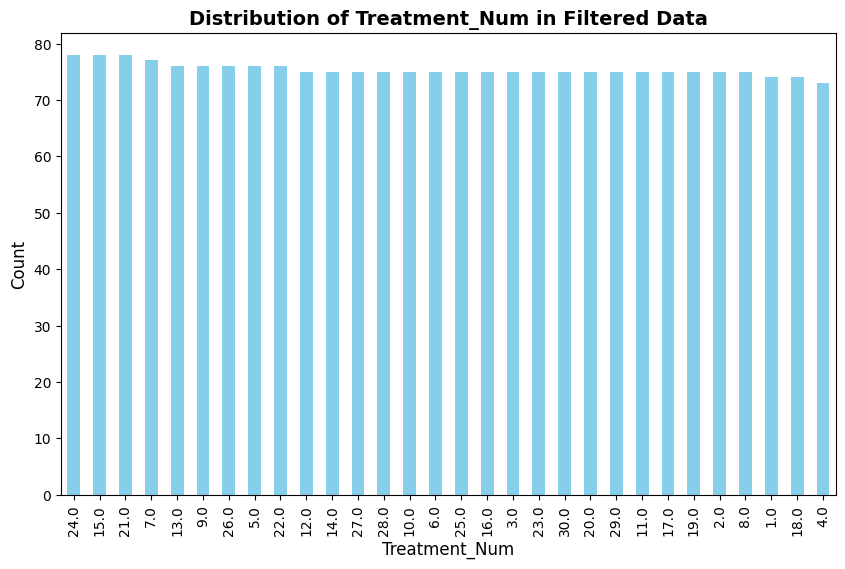

In [5]:
df_imputed['Treatment_Num'].value_counts() \
    .plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Distribution of Treatment_Num in Filtered Data', fontsize=14, fontweight='bold')
plt.xlabel('Treatment_Num', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### Ranking Productividad Imputados

In [6]:
# hacer ranking de los tratamientos para productividad alta y baja
treatment_productivity = df_imputed.groupby('Treatment_Num')['Weight of Harvested Fruits (Kg)'].median().reset_index()
treatment_productivity = treatment_productivity.sort_values(by='Weight of Harvested Fruits (Kg)', ascending=False).reset_index(drop=True)
print("\nRanking de Tratamientos por Productividad (mediana de Weight of Harvested Fruits (Kg)):")
for i, row in treatment_productivity.iterrows():
    print(f"  {i+1}. Treatment {int(row['Treatment_Num'])}: {row['Weight of Harvested Fruits (Kg)']:.2f} Kg")   


Ranking de Tratamientos por Productividad (mediana de Weight of Harvested Fruits (Kg)):
  1. Treatment 29: 0.40 Kg
  2. Treatment 6: 0.33 Kg
  3. Treatment 27: 0.33 Kg
  4. Treatment 10: 0.32 Kg
  5. Treatment 2: 0.32 Kg
  6. Treatment 17: 0.32 Kg
  7. Treatment 20: 0.31 Kg
  8. Treatment 14: 0.28 Kg
  9. Treatment 23: 0.28 Kg
  10. Treatment 9: 0.28 Kg
  11. Treatment 28: 0.26 Kg
  12. Treatment 24: 0.25 Kg
  13. Treatment 21: 0.25 Kg
  14. Treatment 15: 0.24 Kg
  15. Treatment 16: 0.24 Kg
  16. Treatment 18: 0.24 Kg
  17. Treatment 11: 0.23 Kg
  18. Treatment 19: 0.23 Kg
  19. Treatment 12: 0.23 Kg
  20. Treatment 13: 0.23 Kg
  21. Treatment 8: 0.22 Kg
  22. Treatment 1: 0.22 Kg
  23. Treatment 22: 0.21 Kg
  24. Treatment 4: 0.20 Kg
  25. Treatment 26: 0.20 Kg
  26. Treatment 7: 0.20 Kg
  27. Treatment 25: 0.18 Kg
  28. Treatment 30: 0.18 Kg
  29. Treatment 5: 0.16 Kg
  30. Treatment 3: 0.13 Kg


### Productividad Acumulada Imputados

In [7]:
# Organizar por fecha
df_imputed_date_sorted =df_imputed.copy()
df_imputed_date_sorted['Date'] = pd.to_datetime(df_imputed_date_sorted[['Year', 'Month', 'Day']])
df_imputed_date_sorted = df_imputed_date_sorted.sort_values(by=['Date'])
# Hacer una sumatoria de furtos cosechados por tratamiento en total
df_imputed_date_sorted.groupby('Treatment_Num')['Weight of Harvested Fruits (Kg)'].sum().reset_index()

,Treatment_Num,Weight of Harvested Fruits (Kg)
0,1.0,24.3269
1,2.0,27.7940
2,3.0,20.6223
3,4.0,21.7509
4,5.0,20.5200
5,6.0,27.1250
6,7.0,21.7541
7,8.0,26.1879
8,9.0,25.2280
9,10.0,29.4174


## **4. Revisión de Tratamiento vs Productividad**

In [8]:
# df_imputed_date_sorted.to_csv('../BaseDatos/df_imputed_date_sorted.csv', index=False)

### **4.1. Productividad TOTAL Datos Raw (Manual + Movil)**

Recordar que los datos se encuntran por planta en estas bases de datos

In [9]:
# Load Unified data
df_unified = pd.read_csv(R"..\BaseDatos\BD Quindio unificados\Quindio_Movil_Manual_unificado.csv")
df_unified['Treatment_Num'] = df_unified['Tratamiento'].str.extract(r'T(\d+)').astype(float)

# Hacer columna de conteo del registro de tratamientos
df_unified['Count_treatment'] = df_unified.groupby('Treatment_Num').cumcount() + 1

mapeo = {
    "Altura planta (cm)": "Plant_Height (cm)",
    "Clorofila (SPAD)": "Chlorophyll (SPAD)",
    "Numero flores ": "Number of Flowers",
    "Numero frutos cosechados ": "Number of Harvested Fruits",
    "Peso frutos cosechados (Kg)": "Weight of Harvested Fruits (Kg)",
    "Tamanno altura (mm)": "Fruit Height (mm)",
    "pH_savia": "Sap pH",
    "K_savia (ppm)": "Sap K (ppm)",
    "Ca_savia (ppm)": "Sap Ca (ppm)",
    "Na_savia (ppm)": "Sap Na (ppm)",
    "NO3_savia (ppm)": "Sap NO3 (ppm)",
    "Conductividad_savia (mS/cm)": "Sap Conductivity (mS/cm)",
    "pH_suelo_Horiba": "Soil pH Horiba",
    "K_suelo_Horiba (ppm)": "Soil K Horiba (ppm)",
    "Ca_suelo_Horiba (ppm)": "Soil Ca Horiba (ppm)",
    "Na_suelo_Horiba (ppm)": "Soil Na Horiba (ppm)",
    "NO3_suelo_Horiba (ppm)": "Soil NO3 Horiba (ppm)",
    "Conductividad_suelo_Horiba (mS/cm)": "Soil Conductivity Horiba (mS/cm)",
    "Tamanno cintura (mm)": "Fruit Diameter (mm)",
    "N": "Nitrogen",
    "P": "Phosphorus",
    "K": "Potassium",
    "Año": "Year",
    "Mes": "Month",
    "Día": "Day",
    "Tratamiento_num": "Treatment_Num",
    "Fecha": "Date"
}

df_unified.rename(columns=mapeo, inplace=True)

In [10]:
ranking_productivity_weight = df_unified.groupby('Treatment_Num', as_index=False).agg(
    total_harvested=('Weight of Harvested Fruits (Kg)', 'sum'),
    n_records=('Count_treatment', 'max')
).sort_values('total_harvested', ascending=False)
ranking_productivity_weight.to_csv('../Resultados/ranking_productivity_weight.csv', index=False)
display(ranking_productivity_weight)

,Treatment_Num,total_harvested,n_records
26,27.0,35.6960,82
5,6.0,33.2990,82
9,10.0,32.9334,83
19,20.0,32.7875,82
23,24.0,32.7550,85
28,29.0,31.1879,82
7,8.0,30.7329,82
8,9.0,30.5530,83
22,23.0,30.2033,82
13,14.0,30.1392,82


Los datos se encuentran por tratamiento

In [11]:
# df_imputed_date_sorted['Count_treatment'] = df_imputed_date_sorted.\
#     groupby('Treatment_Num').cumcount() + 1


# ranking_productivity_weight = df_imputed_date_sorted.groupby('Treatment_Num', as_index=False).agg(
#     total_harvested=('Weight of Harvested Fruits (Kg)', 'sum'),
#     n_records=('Count_treatment', 'max')
# ).sort_values('total_harvested', ascending=False)
# display(ranking_productivity_weight)

#### **4.1.1 Cuartiles Tratamiento según productividad Total**

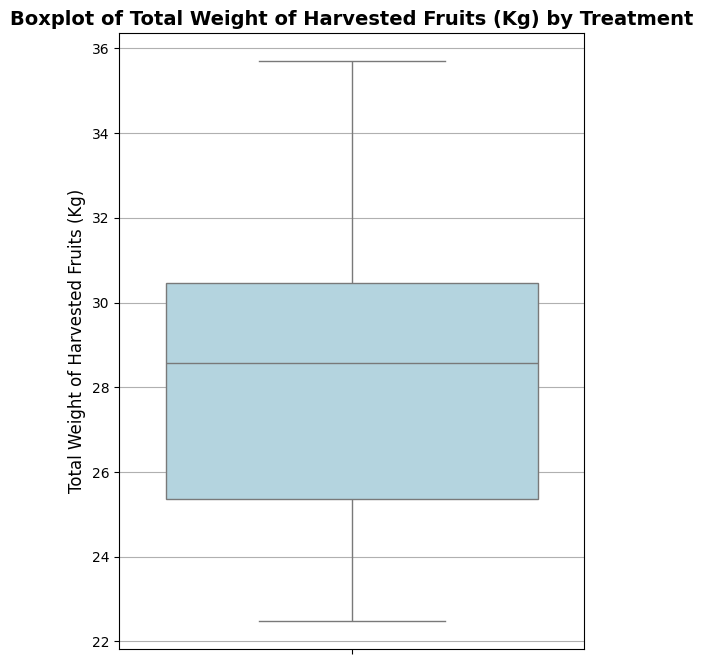

In [12]:
# Graficar boxplot de productividad total ranking_productivity_weight
plt.figure(figsize=(6, 8))
sns.boxplot(y=ranking_productivity_weight['total_harvested'], color='lightblue')
plt.title('Boxplot of Total Weight of Harvested Fruits (Kg) by Treatment', fontsize=14, fontweight='bold')
plt.ylabel('Total Weight of Harvested Fruits (Kg)', fontsize=12)
plt.grid(axis='y')
#save figure

plt.savefig('../Resultados/boxplot_total_harvested_by_treatment.pdf', bbox_inches='tight')

plt.show()


In [13]:
# Obtener cuartiles mayor y menor según productividad
q_high_prod = ranking_productivity_weight['total_harvested'].quantile(0.75)
q_low_prod = ranking_productivity_weight['total_harvested'].quantile(0.25)
print(f"Cuartil superior (75%): {q_high_prod}")
print(f"Cuartil inferior (25%): {q_low_prod}")

Cuartil superior (75%): 30.465575
Cuartil inferior (25%): 25.372799999999998


### Extraer tratamientos según los cuartiles encontrados

In [14]:
treatments_quantile_unified = {}

q_high_prod_unified = ranking_productivity_weight['total_harvested'].quantile(0.75)
q_low_prod_unified = ranking_productivity_weight['total_harvested'].quantile(0.25)
q_mid_prod_unified = ranking_productivity_weight['total_harvested'].quantile(0.50)

lista_high_unified = ranking_productivity_weight['Treatment_Num']\
    .loc[ranking_productivity_weight['total_harvested'] >= q_high_prod_unified]\
    .tolist()
lista_low_unified = ranking_productivity_weight['Treatment_Num']\
    .loc[ranking_productivity_weight['total_harvested'] <= q_low_prod_unified]\
    .tolist()
lista_mid_up_unified = ranking_productivity_weight['Treatment_Num']\
    .loc[(ranking_productivity_weight['total_harvested'] > q_mid_prod_unified) &
         (ranking_productivity_weight['total_harvested'] < q_high_prod_unified)]

lista_mid_low_unified = ranking_productivity_weight['Treatment_Num']\
    .loc[(ranking_productivity_weight['total_harvested'] < q_mid_prod_unified) &
         (ranking_productivity_weight['total_harvested'] > q_low_prod_unified)]

treatments_quantile_unified['4'] = lista_high_unified
treatments_quantile_unified['1'] = lista_low_unified
# treatments_quantile_unified['2'] = lista_mid_up_unified.tolist()
# treatments_quantile_unified['1'] = lista_mid_low_unified.tolist()

with open('../Resultados/treatments_quantile_unified.json', 'w') as f:
    json.dump(treatments_quantile_unified, f, indent=4)


In [15]:
df_unified.columns

Index(['Date', 'Planta', 'Tratamiento', 'Plant_Height (cm)',
       'Diametro tallo (mm)', 'Chlorophyll (SPAD)', 'Number of Flowers',
       'Numero frutos', 'Number of Harvested Fruits',
       'Weight of Harvested Fruits (Kg)', 'Perímetro (mm)',
       'Fruit Height (mm)', 'Frutos de 2da', 'Sap pH', 'Sap K (ppm)',
       'Sap Ca (ppm)', 'Sap Na (ppm)', 'Sap NO3 (ppm)',
       'Sap Conductivity (mS/cm)', 'Fosforo_savia (ppm)', 'Soil pH Horiba',
       'Soil K Horiba (ppm)', 'Soil Ca Horiba (ppm)', 'Soil Na Horiba (ppm)',
       'Soil NO3 Horiba (ppm)', 'Soil Conductivity Horiba (mS/cm)',
       'Fosforo_suelo_Hanna (ppm)', 'Fruit Diameter (mm)',
       '7in1_Nitrogen[mg/kg]', '7in1_Phosphorus[mg/kg]',
       '7in1_Potasium[mg/kg]', '7in1_Ph[pH]', '7in1_Moisture[%RH]',
       '7in1_S_Temperature[C]', '7in1_Conductivity[uS/cm]',
       'Pynamometer_Radiation[W/m^2]', 'Air_sensor_Temperature[C]',
       'Air_sensor_Humidity[%RH]', 'RGB_capture', 'Tapo_capture',
       'Parrot_capture', '

,Treatment_Num,Treatment_Name,Quartil,total_harvested
0,27.0,T27_N2P2K2,4,35.6960
1,6.0,T6_N0P1K1,4,33.2990
2,10.0,T10_N1P0K0,4,32.9334
3,20.0,T20_N2P1K0,4,32.7875
4,24.0,T24_N2P1K1,4,32.7550
5,29.0,T29_BIO N1P1K1,4,31.1879
6,8.0,T8_N0P2K1,4,30.7329
7,9.0,T9_N0P2K2,4,30.5530
8,25.0,T25_N2P1K2,1,25.2911
9,22.0,T22_N2P0K1,1,25.1640


Best treatment (df_quartiles): 27 -> cumulative 35.70
Worst treatment (df_quartiles): 3 -> cumulative 22.48


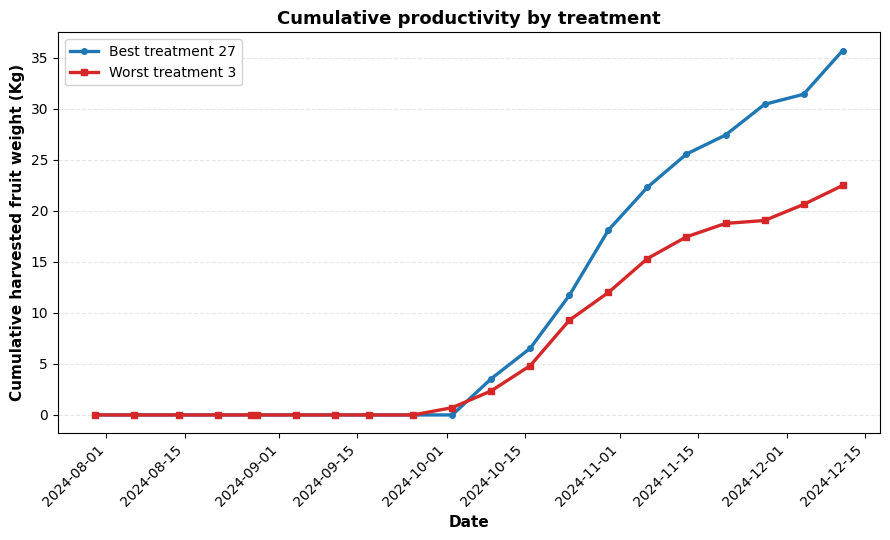

In [ ]:
# Crear DataFrame desde el diccionario de cuartiles
rows = []
for quartil, treatments in treatments_quantile_unified.items():
    for treatment in treatments:
        rows.append({
            'Treatment_Num': treatment,
            'Quartil': int(quartil)
        })

df_quartiles = pd.DataFrame(rows)

# Agregar total_harvested desde ranking_productivity_weight
df_quartiles = df_quartiles.merge(
    ranking_productivity_weight[['Treatment_Num', 'total_harvested']], 
    on='Treatment_Num', 
    how='left'
 )

# Crear nombre del tratamiento en formato TXX_NXPXKX
df_quartiles['Treatment_Name'] = df_quartiles.merge(
    df_unified[['Treatment_Num', 'Tratamiento']].drop_duplicates('Treatment_Num'),
    on='Treatment_Num',
    how='left'
 )['Tratamiento']

# Reordenar columnas
df_quartiles = df_quartiles[['Treatment_Num', 'Treatment_Name', 'Quartil', 'total_harvested']]

# Ordenar por cuartil (descendente) y total_harvested (descendente)
df_quartiles = df_quartiles.sort_values(['Quartil', 'total_harvested'], ascending=[False, False]).reset_index(drop=True)

df_quartiles.to_csv('../Resultados/quartiles_treatments.csv', index=False)

display(df_quartiles)

# Cumulative productivity plot for best and worst treatments
if df_quartiles.empty:
    raise ValueError("df_quartiles is empty.")

best_row = df_quartiles.loc[df_quartiles['total_harvested'].idxmax()]
worst_row = df_quartiles.loc[df_quartiles['total_harvested'].idxmin()]
best_treatment = int(best_row['Treatment_Num'])
worst_treatment = int(worst_row['Treatment_Num'])

if 'Date' not in df_unified.columns:
    df_unified['Date'] = pd.to_datetime(df_unified[['Year', 'Month', 'Day']], errors='coerce')
else:
    df_unified['Date'] = pd.to_datetime(df_unified['Date'], errors='coerce')

required_cols = {'Treatment_Num', 'Date', 'Weight of Harvested Fruits (Kg)'}
missing_cols = sorted(required_cols - set(df_unified.columns))
if missing_cols:
    raise ValueError(f"Missing required columns for cumulative plot: {missing_cols}")

df_plot_base = df_unified.dropna(subset=['Date']).copy()
daily_prod = (
    df_plot_base
    .groupby(['Treatment_Num', 'Date'], as_index=False)['Weight of Harvested Fruits (Kg)']
    .sum()
    .sort_values(['Treatment_Num', 'Date'])
 )

def build_cumulative(df_daily, treatment_num, value_col):
    subset = df_daily[df_daily['Treatment_Num'] == treatment_num].copy()
    subset = subset.sort_values('Date')
    subset['Cumulative'] = subset[value_col].cumsum()
    return subset

best_df = build_cumulative(daily_prod, best_treatment, 'Weight of Harvested Fruits (Kg)')
worst_df = build_cumulative(daily_prod, worst_treatment, 'Weight of Harvested Fruits (Kg)')

if best_df.empty or worst_df.empty:
    raise ValueError("No data found for the selected treatments.")

best_final = float(best_df['Cumulative'].iloc[-1])
worst_final = float(worst_df['Cumulative'].iloc[-1])

print(f"Best treatment (df_quartiles): {best_treatment} -> cumulative {best_final:.2f}")
print(f"Worst treatment (df_quartiles): {worst_treatment} -> cumulative {worst_final:.2f}")

import matplotlib.dates as mdates
fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
ax.plot(
    best_df['Date'],
    best_df['Cumulative'],
    color='#1f77b4',
    linewidth=2.4,
    marker='o',
    markersize=4,
    label=f"Best treatment {best_treatment}",
 )
ax.plot(
    worst_df['Date'],
    worst_df['Cumulative'],
    color='#d62728',
    linewidth=2.4,
    marker='s',
    markersize=4,
    label=f"Worst treatment {worst_treatment}",
 )

ax.set_title('Cumulative productivity by treatment', fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=11, fontweight='bold')
ax.set_ylabel('Cumulative harvested fruit weight (Kg)', fontsize=11, fontweight='bold')
ax.legend(loc='best', framealpha=0.9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()

plt.savefig('../Resultados/cumulative_productivity_best_worst.pdf', bbox_inches='tight')

plt.show()

### Revision por Numero de Frutos Cosechados

In [16]:
(df_unified.groupby('Planta', as_index=False).agg(
    total_harvested=('Number of Harvested Fruits', 'sum'),
    n_records=('Treatment_Num', 'count'),
    treatment = ('Treatment_Num', 'unique')
).sort_values('total_harvested', ascending=False)).head(15)

,Planta,total_harvested,n_records,treatment
119,120,56.0,14,[14.0]
91,92,56.0,14,[9.0]
0,1,52.0,14,[27.0]
3,4,52.0,14,[24.0]
79,80,49.0,14,[6.0]
78,79,49.0,14,[6.0]
139,140,48.0,13,[20.0]
145,146,47.0,13,[6.0]
97,98,47.0,14,[26.0]
155,156,46.0,13,[29.0]


### Filtrar cuartiles de productividad

In [22]:
# Obtener cuartiles mayor y menor según productividad
q_high_prod = ranking_productivity_weight['total_harvested'].quantile(0.75)
q_low_prod = ranking_productivity_weight['total_harvested'].quantile(0.25)
print(f"Cuartil superior (75%): {q_high_prod}")
print(f"Cuartil inferior (25%): {q_low_prod}")

Cuartil superior (75%): 30.465575
Cuartil inferior (25%): 25.372799999999998


In [23]:
lista_high = ranking_productivity_weight['Treatment_Num']\
    .loc[ranking_productivity_weight['total_harvested'] >= q_high_prod]\
    .tolist()
lista_low = ranking_productivity_weight['Treatment_Num']\
    .loc[ranking_productivity_weight['total_harvested'] <= q_low_prod]\
    .tolist()

### Variables más importantes por modelo

In [24]:
# Cargar diccionario variables más importantes por elemento
with open(CFG.class_path + 'most_frequent_variables_80.json', 'r') as f:
    important_vars_dict = json.load(f)

In [25]:
important_vars_dict['Nitrogen'][:5]

['Sap Na (ppm)',
 'Soil pH Horiba',
 'Chlorophyll (SPAD)',
 'Sap Ca (ppm)',
 'Sap NO3 (ppm)']